In [1]:
!pip install wfdb --quiet

import os, ast, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter

from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import wfdb

# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ======= PATHS (KAGGLE) ========
BASE = "/kaggle/input/ecg-detection/ptbl_xl_large_dataset"

DB_CSV  = os.path.join(BASE, "ptbxl_database.csv")
SCP_CSV = os.path.join(BASE, "scp_statements.csv")

print(DB_CSV)
print(SCP_CSV)

# Load metadata + scp statements
db  = pd.read_csv(DB_CSV)
scp = pd.read_csv(SCP_CSV)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.7 MB/s eta 0:00:00
/kaggle/input/ecg-detection/ptbl_xl_large_dataset/ptbxl_database.csv
/kaggle/input/ecg-detection/ptbl_xl_large_dataset/scp_statements.csv


In [2]:
mi_codes = []

for c in scp["Unnamed: 0"].astype(str):
    u = c.upper()
    if any(k in u for k in [
        "MI","IMI","AMI","INFARCTION",
        "STEMI","NSTEMI","INFERIOR MI","ANTERIOR MI","POSTERIOR MI",
        "OLD MI","OMI","PMI","LMI"
    ]):
        mi_codes.append(c)

mi_codes = set(mi_codes)

print("CAD/MI codes:", len(mi_codes))

def parse_scp(x):
    try:
        return set(ast.literal_eval(x).keys())
    except:
        return set()

db["scp_set"] = db["scp_codes"].apply(parse_scp)

def map_label_2class(s):
    if "NORM" in s:
        return 0
    if len(s & mi_codes) > 0:
        return 1
    return None

db["label_2"] = db["scp_set"].apply(map_label_2class)

db2 = db.dropna(subset=["label_2"]).copy()
db2["label_2"] = db2["label_2"].astype(int)

print("Final 2-class distribution:", db2["label_2"].value_counts())


CAD/MI codes: 9
Final 2-class distribution: label_2
0    9514
1    5287
Name: count, dtype: int64


In [19]:
# Current class distribution
cnt = db2["label_2"].value_counts()
print("Before balancing:", cnt.to_dict())

TARGET = 9514  # your desired samples per class

# ---- Separate classes ----
df_norm = db2[db2["label_2"] == 0]
df_cad  = db2[db2["label_2"] == 1]

# ---- Oversample CAD to match TARGET ----
if len(df_cad) < TARGET:
    df_cad_bal = df_cad.sample(TARGET, replace=True, random_state=SEED)
else:
    df_cad_bal = df_cad.sample(TARGET, replace=False, random_state=SEED)

# ---- Oversample NORMAL to match TARGET (if needed) ----
if len(df_norm) < TARGET:
    df_norm_bal = df_norm.sample(TARGET, replace=True, random_state=SEED)
else:
    df_norm_bal = df_norm.sample(TARGET, replace=False, random_state=SEED)

# ---- Combine both ----
db_bal = pd.concat([df_norm_bal, df_cad_bal]).sample(frac=1.0, random_state=SEED)

print("After balancing:")
print(db_bal["label_2"].value_counts())


Before balancing: {0: 9514, 1: 5287}
After balancing:
label_2
0    9514
1    9514
Name: count, dtype: int64


In [20]:
from scipy.signal import butter, filtfilt, resample

TARGET_FS = 500
TARGET_LEN = 5000
NUM_LEADS = 12

def butter_bandpass(low, high, fs, order=4):
    nyq = fs * 0.5
    return butter(order, [low/nyq, high/nyq], btype="band")

def clean_ecg(sig, fs):
    sig = np.nan_to_num(sig)

    if sig.shape[1] < 12:
        sig = np.pad(sig, ((0,0),(0,12-sig.shape[1])))
    else:
        sig = sig[:, :12]

    b,a = butter_bandpass(0.5,40,fs)

    cleaned = []
    for i in range(12):
        cleaned.append(filtfilt(b,a,sig[:,i]))
    cleaned = np.stack(cleaned,axis=1)

    new_len = int(cleaned.shape[0] * TARGET_FS / fs)
    cleaned = np.stack([resample(cleaned[:,i], new_len) for i in range(12)],axis=1)

    if cleaned.shape[0] > TARGET_LEN:
        start = (cleaned.shape[0]-TARGET_LEN)//2
        cleaned = cleaned[start:start+TARGET_LEN]
    else:
        pad = TARGET_LEN-cleaned.shape[0]
        cleaned = np.pad(cleaned,((pad//2,pad-pad//2),(0,0)))

    for i in range(12):
        std = cleaned[:,i].std()
        if std < 1e-6: return None
        cleaned[:,i]=(cleaned[:,i]-cleaned[:,i].mean())/(std+1e-8)

    return cleaned.astype(np.float32)


In [21]:
X_list = []
y_list = []

for _, row in tqdm(db_bal.iterrows(), total=len(db_bal)):
    fpath = os.path.join(BASE, row["filename_hr"]) if isinstance(row["filename_hr"], str) else os.path.join(BASE, row["filename"])

    try:
        rec = wfdb.rdrecord(fpath)
        sig = rec.p_signal
        fs  = rec.fs
    except:
        continue

    clean = clean_ecg(sig, fs)
    if clean is None:
        continue

    X_list.append(clean)
    y_list.append(row["label_2"])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print("Final X:", X.shape)
print("Final y:", Counter(y))

np.save("/kaggle/working/X_ptb_2class.npy", X)
np.save("/kaggle/working/y_ptb_2class.npy", y)


100%|██████████| 19028/19028 [04:55<00:00, 64.35it/s]


Final X: (19026, 5000, 12)
Final y: Counter({0: 9514, 1: 9512})


In [22]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10, stratify=y_temp, random_state=SEED)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: (14554, 5000, 12)
Val  : (1618, 5000, 12)
Test : (2854, 5000, 12)


In [23]:
from tensorflow.keras import layers, models

def SE_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

def res_block(x, filters, k=5):
    shortcut = x
    
    x = layers.Conv1D(filters, k, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, k, padding="same")(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return SE_block(x)

def build_cnn(input_shape=(5000, 12)):
    inp = layers.Input(shape=input_shape)

    # Initial conv layers
    x = layers.Conv1D(32, 7, activation="relu", padding="same")(inp)
    x = layers.Conv1D(32, 5, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    # ResNet blocks
    for f in [32, 64, 128]:
        x = res_block(x, f)
        x = layers.MaxPooling1D(2)(x)

    # Global pooling for CNN only
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    return model

model = build_cnn(input_shape=(X.shape[1], X.shape[2]))
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 5000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 5000, 32)  │      2,720 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 5000, 32)  │      5,152 │ conv1d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 32)  │        128 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 5000, 32)  │      5,152 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 32)  │        128 │ conv1d_23[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 5000, 32)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 5000, 32)  │      5,152 │ re_lu_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 32)  │        128 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 5000, 32)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 5000, 32)  │          0 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ re_lu_13[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 32)        │         96 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 5000, 32)  │          0 │ re_lu_13[0][0],   │
│ (Multiply)          │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 2500, 32)  │          0 │ multiply_6[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 2500, 64)  │     10,304 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2500, 64)  │        256 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 2500, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 2500, 64)  │     20,544 │ re_lu_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 204,079 (797.18 KB)

 Trainable params: 203,119 (793.43 KB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint


classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ckpt_path = "/kaggle/working/cnn_ptb_2class_best.h5"

cbs = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=cbs,
    verbose=1
)


Epoch 1/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8141 - loss: 0.4152
Epoch 1: val_loss improved from inf to 0.26582, saving model to /kaggle/working/cnn_ptb_2class_best.h5


455/455 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.8142 - loss: 0.4150 - val_accuracy: 0.8993 - val_loss: 0.2658 - learning_rate: 1.0000e-04
Epoch 2/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9039 - loss: 0.2457
Epoch 2: val_loss improved from 0.26582 to 0.23085, saving model to /kaggle/working/cnn_ptb_2class_best.h5


455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9039 - loss: 0.2457 - val_accuracy: 0.9079 - val_loss: 0.2308 - learning_rate: 1.0000e-04
Epoch 3/15
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9120 - loss: 0.2183
Epoch 3: val_loss improved from 0.23085 to 0.22222, saving model to /kaggle/working/cnn_ptb_2class_best.h5


455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.9120 - loss: 0.2183 - val_accuracy: 0.9147 - val_loss: 0.2222 - learning_rate: 1.0000e-04
Epoch 4/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9159 - loss: 0.2067
Epoch 4: val_loss improved from 0.22222 to 0.22036, saving model to /kaggle/working/cnn_ptb_2class_best.h5


455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.9159 - loss: 0.2067 - val_accuracy: 0.9110 - val_loss: 0.2204 - learning_rate: 1.0000e-04
Epoch 5/15
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9215 - loss: 0.2027
Epoch 5: val_loss improved from 0.22036 to 0.20093, saving model to /kaggle/working/cnn_ptb_2class_best.h5


455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.9215 - loss: 0.2027 - val_accuracy: 0.9221 - val_loss: 0.2009 - learning_rate: 1.0000e-04
Epoch 6/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9272 - loss: 0.1896
Epoch 6: val_loss improved from 0.20093 to 0.18885, saving model to /kaggle/working/cnn_ptb_2class_best.h5


455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.9272 - loss: 0.1896 - val_accuracy: 0.9246 - val_loss: 0.1888 - learning_rate: 1.0000e-04
Epoch 7/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9327 - loss: 0.1731
Epoch 7: val_loss did not improve from 0.18885
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9327 - loss: 0.1731 - val_accuracy: 0.9166 - val_loss: 0.2084 - learning_rate: 1.0000e-04
Epoch 8/15
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9325 - loss: 0.1711
Epoch 8: val_loss improved from 0.18885 to 0.18340, saving model to /kaggle/working/cnn_ptb_2class_best.h5


455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.9325 - loss: 0.1711 - val_accuracy: 0.9265 - val_loss: 0.1834 - learning_rate: 1.0000e-04
Epoch 9/15
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9408 - loss: 0.1545
Epoch 9: val_loss did not improve from 0.18340
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9408 - loss: 0.1546 - val_accuracy: 0.9215 - val_loss: 0.1859 - learning_rate: 1.0000e-04
Epoch 10/15
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9383 - loss: 0.1601
Epoch 10: val_loss did not improve from 0.18340
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9383 - loss: 0.1600 - val_accuracy: 0.9289 - val_loss: 0.1927 - learning_rate: 1.0000e-04
Epoch 11/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9466 - loss: 0.1420
Epoch 11: val_loss improved from 0.18340 to 0.17659, saving model to /kaggle/working/cnn_ptb_2class_best.h5


455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9466 - loss: 0.1420 - val_accuracy: 0.9363 - val_loss: 0.1766 - learning_rate: 1.0000e-04
Epoch 12/15
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9485 - loss: 0.1383
Epoch 12: val_loss did not improve from 0.17659
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9485 - loss: 0.1383 - val_accuracy: 0.9345 - val_loss: 0.1802 - learning_rate: 1.0000e-04
Epoch 13/15
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9465 - loss: 0.1365
Epoch 13: val_loss did not improve from 0.17659
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9465 - loss: 0.1365 - val_accuracy: 0.9252 - val_loss: 0.1910 - learning_rate: 1.0000e-04
Epoch 14/15
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9454 - loss: 0.1404
Epoch 14: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 14: val_loss did not improve from 0.17659
455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9454 - loss: 0.1

455/455 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.9576 - loss: 0.1174 - val_accuracy: 0.9382 - val_loss: 0.1707 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 15.


Loaded best CNN model.
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step

Accuracy: 0.9414856341976173

Classification Report:

              precision    recall  f1-score   support

           0     0.9418    0.9411    0.9415      1427
           1     0.9412    0.9418    0.9415      1427

    accuracy                         0.9415      2854
   macro avg     0.9415    0.9415    0.9415      2854
weighted avg     0.9415    0.9415    0.9415      2854



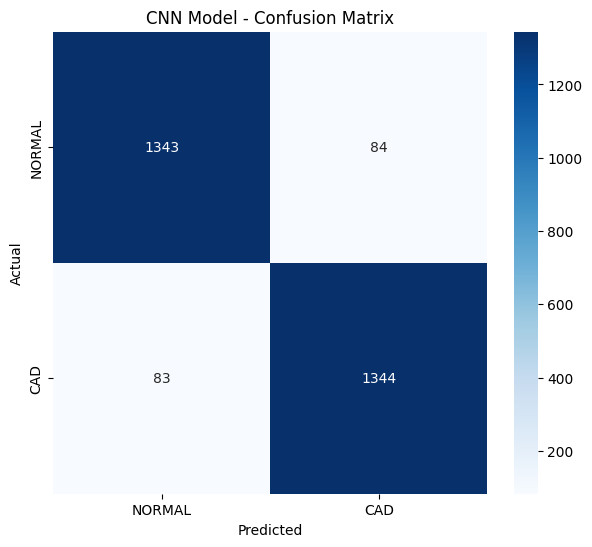

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load best weights
model.load_weights(ckpt_path)
print("Loaded best CNN model.")

# CNN Predictions
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int).reshape(-1)

# --- Accuracy ---
print("\nAccuracy:", accuracy_score(y_test, y_pred))

# --- Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL","CAD"],
    yticklabels=["NORMAL","CAD"]
)
plt.title("CNN Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


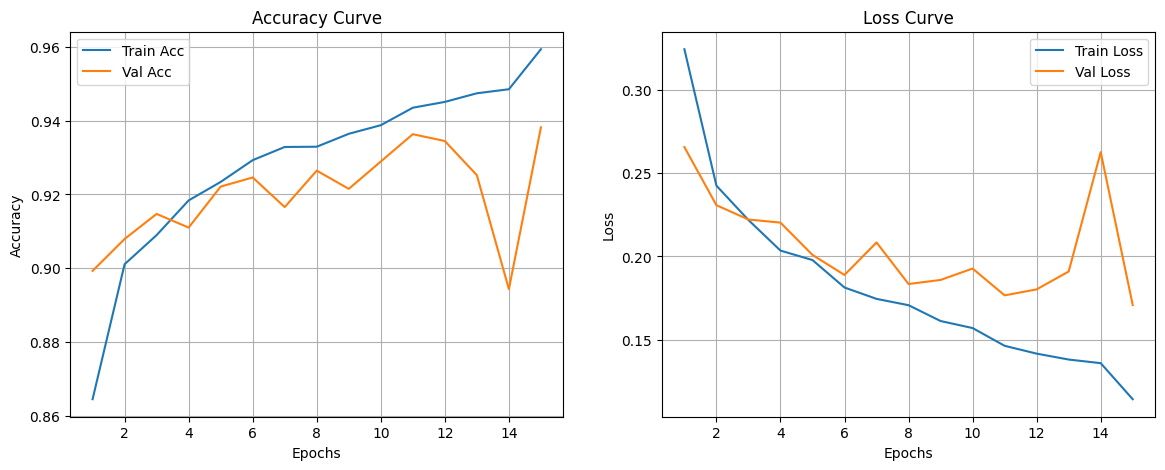

In [26]:
# ==== CELL: Accuracy & Loss Graphs ====
import matplotlib.pyplot as plt

acc      = history.history["accuracy"]
val_acc  = history.history["val_accuracy"]
loss     = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc)+1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()


In [28]:
# ==== CELL: Signal formatting ====
from scipy.signal import resample

def format_sig_5000x12(sig):
    sig = np.array(sig, dtype="float32")

    if sig.ndim == 1:
        sig = sig[:, None]

    if sig.shape[0] < sig.shape[1] and sig.shape[0] <= 12:
        sig = sig.T

    if sig.shape[1] < 12:
        sig = np.pad(sig, ((0,0),(0,12-sig.shape[1])), 'constant')
    elif sig.shape[1] > 12:
        sig = sig[:, :12]

    L = sig.shape[0]
    if L != 5000:
        out = np.zeros((5000, 12), dtype="float32")
        for i in range(12):
            out[:, i] = resample(sig[:, i], 5000)
    else:
        out = sig

    # normalize
    for i in range(12):
        m, s = out[:,i].mean(), out[:,i].std()
        if s < 1e-6: out[:,i] = 0
        else:        out[:,i] = (out[:,i] - m) / (s+1e-8)

    return out


In [29]:
import wfdb
import pandas as pd
import os

def load_npy(path):
    return format_sig_5000x12(np.load(path))

def load_csv(path):
    df = pd.read_csv(path)
    return format_sig_5000x12(df.to_numpy())

def load_dat(path):
    if path.endswith(".dat"):
        path = path[:-4]

    rec = wfdb.rdrecord(path)
    return format_sig_5000x12(rec.p_signal)


In [30]:
CLASS = {0: "NORMAL", 1: "CAD"}

def predict_ecg(path):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".dat":
        sig = load_dat(path)
    elif ext == ".npy":
        sig = load_npy(path)
    elif ext == ".csv":
        sig = load_csv(path)
    else:
        raise ValueError("Unsupported file type")

    sig = np.expand_dims(sig, axis=0)

    prob = float(model.predict(sig)[0][0])
    pred = int(prob >= 0.5)

    print("\n========= PREDICTION =========")
    print("File  :", path)
    print("Class :", CLASS[pred])
    print(f"Prob(CAD): {prob:.4f}")
    print(f"Prob(NORMAL): {1-prob:.4f}")

    return pred, prob


In [41]:
predict_ecg("/kaggle/input/ecg-detection/ptbl_xl_large_dataset/records500/00000/00039_hr.dat")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

========= PREDICTION =========
File  : /kaggle/input/ecg-detection/ptbl_xl_large_dataset/records500/00000/00039_hr.dat
Class : CAD
Prob(CAD): 0.9688
Prob(NORMAL): 0.0312


(1, 0.9687660336494446)